[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Gradient Descent and Stochastic Gradient Descent

Every network in this course was trained using some form of gradient descent with the same code structure:

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

We have been explicit about what `backward()` does, namely backpropagation.  In this module we go deeper into how optimizers work beyond "subtract the gradient times a learning rate".  We will also justify the choice of optimizer — `SGD` for convolutional networks, and `Adam` for transformers.

This module is composed of four notebooks:

1. **this one** — gradient descent, what the learning rate controls, and what
   changes when the gradient is estimated from a sample rather than computed
   exactly;
2. **minibatches and momentum** — the two fixes for the two problems this
   notebook ends with;
3. **adaptive methods** — AdaGrad, RMSProp and Adam, and the kind of problem
   on which they are worth their extra state;
4. **learning rate schedules** — including the warmup that transformers need.

Our real goal in machine learning is low error on unseen data.  The training loss is a proxy for it.
But keep in mind that a method that drives the training loss down faster is not automatically the method that generalizes better, and we will see a concrete case of that in notebook 3.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import math
import time

import numpy as np
import torch
from matplotlib import pyplot as plt

## Gradient descent in one dimension

Take an objective function $f: \mathbb{R} \to \mathbb{R}$ that we want to minimize.  A
Taylor expansion around $x$ says that for a small step $\epsilon$,

$$f(x + \epsilon) = f(x) + \epsilon f'(x) + \mathcal{O}(\epsilon^2).$$

The first-order term is the one we can control.  If we choose
$\epsilon = -\eta f'(x)$ for a positive $\eta$, then

$$f\bigl(x - \eta f'(x)\bigr) = f(x) - \eta f'^2(x) + \mathcal{O}(\eta^2 f'^2(x)),$$

and since $f'^2(x) \ge 0$, the value goes *down* — provided $\eta$ is small
enough that the $\mathcal{O}(\eta^2)$ term has not taken over.

This gives the update

$$x \leftarrow x - \eta f'(x),$$

and $\eta$ is the **learning rate**.  Let us watch it work on $f(x) = x^2$,
whose minimum is at $x = 0$.

In [2]:
def f(x):
    return x ** 2

def f_grad(x):
    return 2 * x

def gd(eta, f_grad, x=10.0, steps=10):
    """Gradient descent from x, returning the whole trajectory."""
    trace = [x]
    for _ in range(steps):
        x -= eta * f_grad(x)
        trace.append(float(x))
    print(f'after {steps} steps, x = {x:f}')
    return trace

trace = gd(0.2, f_grad)

after 10 steps, x = 0.060466


To see what happened, we plot the objective and mark where each step landed:

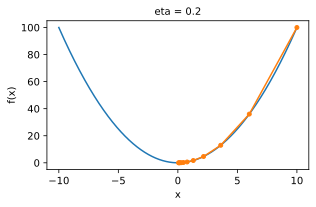

In [3]:
def show_trace(trace, f, title=None):
    """Plot f, with the iterates of an optimizer marked on it."""
    n = max(abs(min(trace)), abs(max(trace)), 10.0)
    line = torch.arange(-n, n, 0.01)
    plt.figure(figsize=(4.5, 3))
    plt.plot(line, [f(x) for x in line])
    plt.plot(trace, [f(x) for x in trace], '-o', color='#ff7f0e', markersize=4)
    plt.xlabel('x'); plt.ylabel('f(x)')
    if title:
        plt.title(title, fontsize=10)
    plt.tight_layout()

show_trace(trace, f, 'eta = 0.2')

## The role of the learning rate

The steps above shrink geometrically, because for $f = x^2$ the update is
exactly $x \leftarrow (1 - 2\eta)\,x$.  With $\eta = 0.2$ each step multiplies
$x$ by $0.6$.  That observation tells us what to expect at other learning rates
without running anything: the factor is $|1 - 2\eta|$, so we converge whenever
$0 < \eta < 1$, slowly when $\eta$ is near either end, and diverge above $1$.

When the learning rate is small convergence is slow:

after 10 steps, x = 3.486784


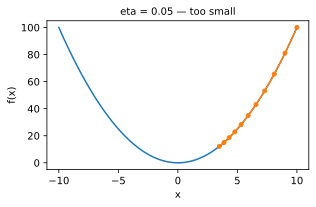

In [4]:
show_trace(gd(0.05, f_grad), f, 'eta = 0.05 — too small')

The factor is $0.9$, so after ten steps $x$ has only fallen to
$10 \times 0.9^{10} \approx 3.5$.  Nothing is wrong; there is simply not enough
progress per step.

Next, let's see what happens when the learning rate is too large:

after 10 steps, x = 61.917364


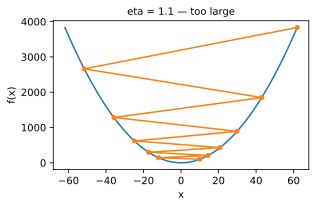

In [5]:
show_trace(gd(1.1, f_grad), f, 'eta = 1.1 — too large')

The factor is $|1 - 2.2| = 1.2 > 1$, so each step overshoots the minimum.  
Here the Taylor series argument has broken down: the step is no longer small enough for the first-order term to dominate.

Between these two lies a range of usable learning rates, and where that range
sits depends on the curvature of $f$.  For $f = x^2$, whose second derivative
is $2$, the boundary is $\eta = 1$.  For $f = 50x^2$ it would be $\eta = 0.02$.
**The largest usable learning rate is set by the largest curvature the
objective has anywhere the optimizer travels** — a fact that will come back in
the next notebook.

### Local minima

The function $f = x^2$ is convex, so there is one minimum and any convergent learning rate
finds it.  Deep networks are not convex.  Consider
$f(x) = x \cos(cx)$, which has infinitely many local minima.

after 10 steps, x = -1.528166


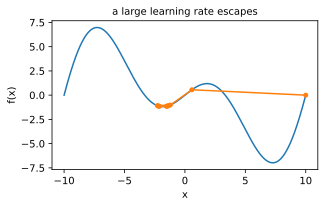

In [6]:
c_w = torch.tensor(0.15 * np.pi)

def f_wiggly(x):
    return x * torch.cos(c_w * x)

def f_wiggly_grad(x):
    return torch.cos(c_w * x) - c_w * x * torch.sin(c_w * x)

show_trace(gd(2, f_wiggly_grad), f_wiggly, 'a large learning rate escapes')

With this (deliberately large) learning rate the iterates does not settle into the nearest local minimum.

It is tempting to conclude that local minima are the central difficulty of
training deep networks.  The evidence says otherwise.  Empirically, the local minima that large
networks do reach are typically comparable.
In practice the difficulties typically comes from regions in which the objective function is flat or has badly scaled curvature, from noisy gradient estimates, and inappropriate step sizes.

## More than one dimension

When working in $d$ dimensions the derivative is replaced by the **gradient**.  
The objective function $f: \mathbb{R}^d \to \mathbb{R}$ has a gradient defined by:

$$\nabla f(\mathbf{x}) =
\Bigl[\frac{\partial f}{\partial x_1}, \ldots,
      \frac{\partial f}{\partial x_d}\Bigr]^\top.$$

Each element in the gradient indicates how fast $f$ changes along that coordinate.  The update is now

$$\mathbf{x} \leftarrow \mathbf{x} - \eta \nabla f(\mathbf{x}).$$

Let's look at an example where the function has different curvature in different directions:

In [7]:
def train_2d(trainer, f_grad, steps=20, init=(-5, -2)):
    """Run a 2D optimizer, returning the list of visited points.

    `trainer` takes (x1, x2, s1, s2, f_grad) and returns the same four values.
    `s1` and `s2` carry optimizer state; gradient descent leaves them at zero."""
    x1, x2 = init
    s1 = s2 = 0
    trace = [(x1, x2)]
    for _ in range(steps):
        x1, x2, s1, s2 = trainer(x1, x2, s1, s2, f_grad)
        trace.append((x1, x2))
    print(f'after {steps} steps, x1 = {x1:.6f}, x2 = {x2:.6f}')
    return trace


def show_trace_2d(f, trace, title=None, xlim=(-5.5, 1.0), ylim=(-3.0, 1.0),
                  labels=('x1', 'x2'), levels=None, ax=None):
    """Contours of f with an optimizer's path drawn over them."""
    if ax is None:
        plt.figure(figsize=(4.5, 3))
        ax = plt.gca()
    ax.plot(*zip(*trace), '-o', color='#ff7f0e', markersize=3)
    x1, x2 = torch.meshgrid(torch.linspace(*xlim, 100),
                            torch.linspace(*ylim, 100), indexing='ij')
    ax.contour(x1, x2, f(x1, x2), colors='#1f77b4', linewidths=0.7, levels=levels)
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1])
    if title:
        ax.set_title(title, fontsize=10)
    plt.tight_layout()

Take $f(\mathbf{x}) = x_1^2 + 2x_2^2$ and start at $(-5, -2)$.

after 20 steps, x1 = -0.057646, x2 = -0.000073


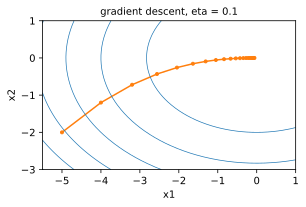

In [8]:
def f_2d(x1, x2):
    return x1 ** 2 + 2 * x2 ** 2

def f_2d_grad(x1, x2):
    return 2 * x1, 4 * x2

def gd_2d(x1, x2, s1, s2, f_grad):
    g1, g2 = f_grad(x1, x2)
    return x1 - eta * g1, x2 - eta * g2, 0, 0

eta = 0.1
show_trace_2d(f_2d, train_2d(gd_2d, f_2d_grad), 'gradient descent, eta = 0.1')

In this example twenty steps bring us close to the minimum at the
origin.  Notice that the path is not straight.  The gradient points along the
steepest *local* descent direction, which is perpendicular to the contour
lines, and since the contours here are ellipses rather than circles that
direction does not point at the minimum.  The optimizer takes a curved route.

The ellipses in this example are mild — the curvature is $2$ along $x_1$ and
$4$ along $x_2$, a ratio of two.  In the next notebook we will see what happens when that
ratio is ten thousand.

## An aside: why not use curvature?

If the trouble is that a single $\eta$ cannot serve directions of different
curvature, the obvious fix is to measure the curvature and divide by it.  That
is **Newton's method**.  Expanding to second order,

$$f(\mathbf{x} + \boldsymbol{\epsilon}) \approx f(\mathbf{x}) +
  \boldsymbol{\epsilon}^\top \nabla f(\mathbf{x}) +
  \tfrac{1}{2} \boldsymbol{\epsilon}^\top \mathbf{H} \boldsymbol{\epsilon},$$

where $\mathbf{H} = \nabla^2 f(\mathbf{x})$ is the **Hessian**, the matrix of
second derivatives.  Setting the derivative with respect to
$\boldsymbol{\epsilon}$ to zero gives
$\boldsymbol{\epsilon} = -\mathbf{H}^{-1} \nabla f(\mathbf{x})$.  There is no
learning rate at all: on a quadratic, this jumps to the exact minimum in one
step, whatever the curvature happens to be.

It works beautifully when $f$ is convex.

  step 1: x = 8.00018
  step 2: x = 6.00152
  step 3: x = 4.0114
  step 4: x = 2.08254
  step 5: x = 0.525763
  step 6: x = 0.0117856
  step 7: x = 1.36933e-07
  step 8: x = -1.67227e-15
after 8 steps, x = -1.67227e-15


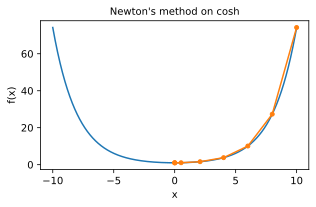

In [9]:
c_h = torch.tensor(0.5)

def f_cosh(x):
    return torch.cosh(c_h * x)

def f_cosh_grad(x):
    return c_h * torch.sinh(c_h * x)

def f_cosh_hess(x):
    return c_h ** 2 * torch.cosh(c_h * x)

def newton(f_grad, f_hess, eta=1.0, x=10.0, steps=8, verbose=False):
    trace = [x]
    for i in range(steps):
        x -= eta * f_grad(torch.tensor(x)).item() / f_hess(torch.tensor(x)).item()
        trace.append(x)
        if verbose:
            print(f'  step {i + 1}: x = {x:.6g}')
    print(f'after {steps} steps, x = {x:g}')
    return trace

show_trace(newton(f_cosh_grad, f_cosh_hess, verbose=True), f_cosh,
           "Newton's method on cosh")

Look at the printed steps rather than the picture, because they show two
different regimes.  The first four are almost exactly $2$ apart —
$10 \to 8 \to 6 \to 4$ — because far from the origin $\cosh$ grows
exponentially and the ratio $f' / f''$ is nearly constant, so Newton crawls in
at a fixed rate.  Then, once inside the region where the quadratic
approximation is good, it converges *quadratically*: $0.526 \to 0.0118 \to
1.4 \times 10^{-7} \to 3.4 \times 10^{-15}$, roughly doubling the number of
correct digits each step.  That second regime is what makes Newton's method
famous.

Now the nonconvex function from before.

In [10]:
def f_wiggly_hess(x):
    return -2 * c_w * torch.sin(c_w * x) - x * c_w ** 2 * torch.cos(c_w * x)

trace = newton(f_wiggly_grad, f_wiggly_hess, verbose=True)
print(f"f'' at the final point = {f_wiggly_hess(torch.tensor(trace[-1])).item():.3f}")
print(f'f went from {f_wiggly(torch.tensor(10.0)).item():.3f} '
      f'to {f_wiggly(torch.tensor(trace[-1])).item():.3f}')

  step 1: x = 5
  step 2: x = 24.9949
  step 3: x = 27.7831
  step 4: x = 26.8001
  step 5: x = 26.8342
  step 6: x = 26.8341
  step 7: x = 26.8341
  step 8: x = 26.8341
after 8 steps, x = 26.8341
f'' at the final point = -6.015
f went from 0.000 to 26.751


We asked for a minimum and got $f = 26.75$, up from $0.0$ where we started —
and the second derivative at the point it settled on is $-6.01$, which makes it
a local **maximum**.  The method converged, confidently, to the worst kind of
answer.

The reason is structural.  Newton's method divides by the curvature; where the
curvature is *negative* — near a maximum, or on the wrong side of a saddle —
dividing by it flips the sign of the step and we walk deliberately uphill.
Newton's method does not seek minima.  It seeks **stationary points**, and a
maximum or a saddle is as attractive to it as a minimum.  In a network with
millions of parameters, where saddles vastly outnumber minima, that is exactly
the wrong instinct.

The second objection is arithmetic.  For $d$ parameters the Hessian has $d^2$
entries and inverting it costs $\mathcal{O}(d^3)$.  For the small GPT of module
08, $d \approx 10^7$; the Hessian alone would need about $4 \times 10^{14}$
bytes.  Quasi-Newton methods (L-BFGS and relatives) approximate
$\mathbf{H}^{-1}$ from a short history of gradients and are genuinely useful on
smaller, deterministic problems, but they assume gradients accurate enough to
build a curvature estimate from — which, as the next section explains, is not
the situation we are in.

So we keep the first-order update, and everything else in this module is a way
of getting *some* of the benefit of curvature information without ever forming
$\mathbf{H}$.  Momentum does it by averaging gradients over time.  Adam does it
by keeping a per-parameter estimate of gradient magnitude.  Neither is Newton's
method; both are cheap.

## Stochastic gradient descent

In deep learning the objective is an average over a training set of $n$ examples,

$$f(\mathbf{x}) = \frac{1}{n} \sum_{i=1}^{n} f_i(\mathbf{x}),$$

where $f_i$ is the loss on example $i$.  Its gradient is therefore also an
average,

$$\nabla f(\mathbf{x}) = \frac{1}{n} \sum_{i=1}^{n} \nabla f_i(\mathbf{x}),$$

and computing it exactly costs $\mathcal{O}(n)$ — one forward and backward pass
over the *entire* training set for a single parameter update.  On ImageNet that
is 1.2 million images per step.  Gradient descent as described above is
unusable at that scale, and the reason has nothing to do with the quality of
its steps: it is that the steps are far too expensive.

**Stochastic gradient descent** replaces the average with an update based on a single randomly
drawn training example:

$$\mathbf{x} \leftarrow \mathbf{x} - \eta \nabla f_i(\mathbf{x}),
\qquad i \sim \mathrm{Uniform}\{1, \ldots, n\}.$$

The cost per step drops from $\mathcal{O}(n)$ to $\mathcal{O}(1)$, and the estimate is still correct *on average*:

$$\mathbb{E}_i\bigl[\nabla f_i(\mathbf{x})\bigr] = \nabla f(\mathbf{x}).$$

The trade at the heart of the method is that we give up knowing the exact gradient
in exchange for taking $n$ times as many steps with the same budget, and an
unbiased estimate is enough for the average behaviour to be right.

Put that way it sounds like a bargain we are forced into by cost.  But it gets better.
Labelled datasets are full of examples that resemble one another.  Similar examples
produce similar gradients, and averaging those gradients doesn't contribute much.
Taken to an extreme, a dataset that happens to contain every example twice has exactly the same gradient as the original, at twice the price per step.

In other words, computing the exact gradient is not only expensive - it is mostly redundant.

To watch a stochastic step behave, we turn to real data.
We take 442 patients from the diabetes dataset that ships
with scikit-learn and predict disease progression one year on from two
standardized measurements — body mass index and a blood serum level.  Two
features, and a least-squares loss whose contours are ellipses
much like the example above.  This time the ellipses come from data.

In [11]:
from sklearn.datasets import load_diabetes

def two_feature_problem():
    """A real least-squares problem with exactly two parameters.

    Features and target are standardized, so no bias term is needed and the
    two weights are on the same scale."""
    dataset = load_diabetes()
    columns = [dataset.feature_names.index(name) for name in ('bmi', 's5')]
    X = torch.tensor(dataset.data[:, columns], dtype=torch.float32)
    y = torch.tensor(dataset.target, dtype=torch.float32)
    return (X - X.mean(0)) / X.std(0), (y - y.mean()) / y.std()

X, y = two_feature_problem()

def f_data(w1, w2):
    """The objective: mean squared error over the whole training set."""
    w1, w2 = torch.as_tensor(w1), torch.as_tensor(w2)
    residual = w1[..., None] * X[:, 0] + w2[..., None] * X[:, 1] - y
    return 0.5 * (residual ** 2).mean(-1)

def grad_all(w1, w2):
    """The exact gradient: the average over all n examples."""
    residual = w1 * X[:, 0] + w2 * X[:, 1] - y
    return (residual * X[:, 0]).mean().item(), (residual * X[:, 1]).mean().item()

def grad_one(w1, w2, i):
    """The gradient of the loss on example i by itself."""
    residual = w1 * X[i, 0] + w2 * X[i, 1] - y[i]
    return (residual * X[i, 0]).item(), (residual * X[i, 1]).item()

curvatures = torch.linalg.eigvalsh(X.T @ X / len(X))
w_star = torch.linalg.lstsq(X, y.unsqueeze(1)).solution.squeeze(1)
print(f'{len(X)} examples, 2 parameters')
print(f'curvatures {curvatures[0]:.2f} and {curvatures[1]:.2f}, '
      f'a ratio of {curvatures[1] / curvatures[0]:.1f}')
print(f'least-squares solution w* = ({w_star[0]:.3f}, {w_star[1]:.3f})')

442 examples, 2 parameters
curvatures 0.55 and 1.44, a ratio of 2.6
least-squares solution w* = (0.417, 0.380)


Now let's run both methods from the same starting point at the same learning rate:
gradient descent averaging all 442 examples per step, and SGD using one.

gradient descent  final distance from w* 0.018, mean over the last 25 steps 0.105
SGD               final distance from w* 0.280, mean over the last 25 steps 0.217


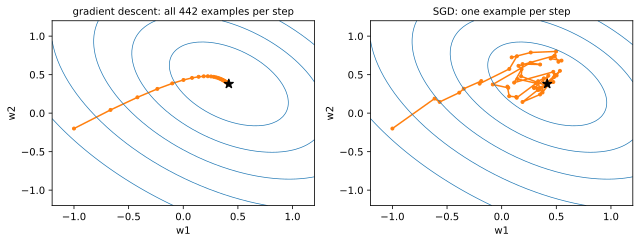

In [12]:
def descend(eta, steps, stochastic=False, init=(-1.0, -0.2), seed=0):
    """Gradient descent, or SGD if `stochastic`; returns the path taken."""
    torch.manual_seed(seed)
    w1, w2 = init
    trace = [(w1, w2)]
    for _ in range(steps):
        if stochastic:
            i = torch.randint(len(X), (1,)).item()       # one example, at random
            g1, g2 = grad_one(w1, w2, i)
        else:
            g1, g2 = grad_all(w1, w2)
        w1, w2 = w1 - eta * g1, w2 - eta * g2
        trace.append((w1, w2))
    return np.array(trace)


eta = 0.2
paths = {f'gradient descent: all {len(X)} examples per step': descend(eta, 30),
         'SGD: one example per step': descend(eta, 50, stochastic=True)}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (title, trace) in zip(axes, paths.items()):
    show_trace_2d(f_data, trace, title, xlim=(-1.2, 1.2), ylim=(-1.2, 1.2),
                  labels=('w1', 'w2'), levels=np.geomspace(0.05, 2.0, 10), ax=ax)
    ax.plot([w_star[0]], [w_star[1]], '*', color='black', markersize=10)

for title, trace in paths.items():
    distance = np.linalg.norm(trace - w_star.numpy(), axis=1)
    print(f'{title.split(":")[0]:17s} final distance from w* {distance[-1]:.3f}, '
          f'mean over the last 25 steps {distance[-25:].mean():.3f}')

At the beginning, the SGD path approximates that of the true gradient.
Near the minimum the true gradient goes to zero while SGD fails to settle.
Running longer won't help.
The only two things that shrink it are averaging more examples per step, which reduces
the disagreement, and shrinking the learning rate. 
Those are the subjects of the next notebook and the last one respectively.

The noise of SGD is not all bad news:  its stochasticity can help the optimizer get "unstuck" at a saddle point where a full gradient computation would meander much longer.
And the noise acts as a mild regularizer, which is part of why models trained with
small batches often generalize slightly better than the same models trained
with very large ones.

## Summary

* Gradient descent follows $\mathbf{x} \leftarrow \mathbf{x} - \eta \nabla f(\mathbf{x})$.
  The learning rate must be small enough for the first-order Taylor
  approximation to hold and large enough to make progress; the ceiling is set
  by the largest curvature along the path.
* Curvature information would remove the need to guess $\eta$, but Newton's
  method is drawn to saddle points as much as to minima and needs a $d \times d$
  Hessian.  Neither is acceptable for deep networks.
* The objective is an average over $n$ examples, so an exact gradient costs a
  full pass over the data.  SGD replaces it with a one-example estimate that is
  unbiased and $n$ times cheaper.
* The exact gradient is also largely redundant: real datasets are full of
  examples that resemble one another, so a full-batch step pays $n$ gradient
  evaluations for a direction a small sample already supplies.  The next
  notebook measures how small.
* A constant learning rate leaves SGD with a noise floor: it converges to a
  region around the minimum, not to the minimum.

Two problems are left open, and the next notebook takes both.  Processing one
example at a time wastes the hardware — a matrix-vector product uses a fraction
of the arithmetic throughput a matrix-matrix product does — which
**minibatching** fixes.  And a single learning rate cannot serve directions of
very different curvature, which **momentum** substantially fixes.

## Exercises

1. For $f(x) = x^2$ the update is $x \leftarrow (1 - 2\eta)x$.  Derive the
   analogous factor for $f(x) = ax^2$ and use it to predict the learning rate
   at which gradient descent diverges.  Check your prediction numerically.
2. Run `gd` on $f(x) = x \cos(cx)$ from several starting points with
   $\eta = 0.1$.  How many distinct minima do you reach?  Now try $\eta = 2$.
   What does this suggest about the role of the learning rate early in
   training?
3. `show_trace_2d` uses $f = x_1^2 + 2x_2^2$, a curvature ratio of $2$.  Change
   it to $f = 0.1x_1^2 + 2x_2^2$, a ratio of $40$, and find the largest $\eta$
   that does not diverge.  How many steps does it then take to make real
   progress along $x_1$?  (This is exactly the experiment that opens the next
   notebook.)
4. Change `descend` to average the gradients of $k$ examples per step instead
   of one, and run it for $k = 1, 4, 16, 64$ with $\eta = 0.2$.  Measure the
   mean distance from $\mathbf{w}^*$ over the last 25 of 50 steps.  How does
   the radius scale with $k$?  (This is the subject of the next notebook.)
5. Then hold $k = 1$ and vary $\eta$ over $\{0.4, 0.2, 0.1, 0.05, 0.01\}$,
   running 500 steps and averaging the distance over the last 100.  You should
   see the noise floor shrink and the approach slow down.  Sketch the schedule
   this suggests.  (This is the subject of the last notebook.)
6. Newton's method on $f = x\cos(c x)$ converged to a maximum.  One proposed
   repair is to use $|f''|$ in place of $f''$, so that the step always points
   downhill.  Implement it and rerun from $x = 10$.  Does it converge, and is
   the point it converges to a minimum?
7. The constant for the wiggly function is named `c_w` and the one for
   $\cosh$ is `c_h`.  Rename both to `c` and rerun the notebook from the top.
   The nonconvex Newton example now gives a different — and wrong — answer,
   with no error raised.  Explain what happened, and say which of Python's
   scoping rules makes it possible.